[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\OWAIS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OWAIS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OWAIS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Shape: (522, 5)

Columns: Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text'], dtype='object')
Text cleaning completed ✅

Sentiment Distribution:
sentiment
Neutral     205
Positive    199
Negative    118
Name: count, dtype: int64


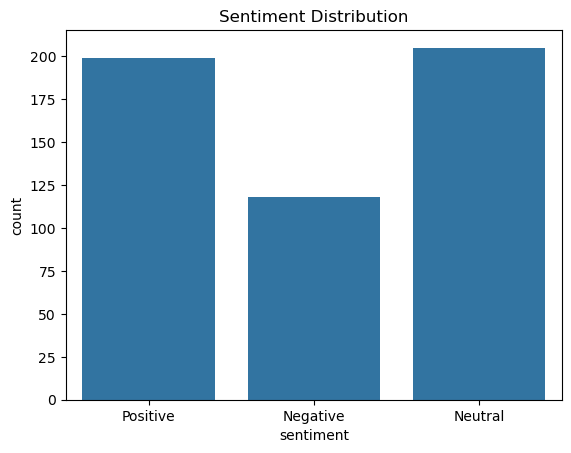

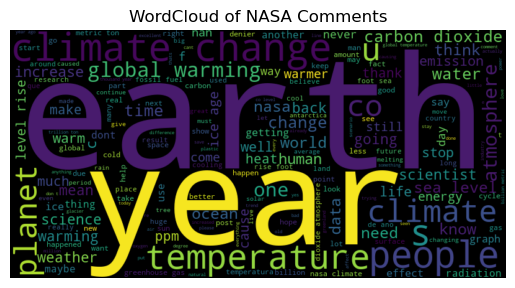


Model Accuracy: 0.6571428571428571

Classification Report:

              precision    recall  f1-score   support

    Negative       0.60      0.15      0.24        20
     Neutral       0.68      0.76      0.72        45
    Positive       0.64      0.80      0.71        40

    accuracy                           0.66       105
   macro avg       0.64      0.57      0.56       105
weighted avg       0.65      0.66      0.62       105



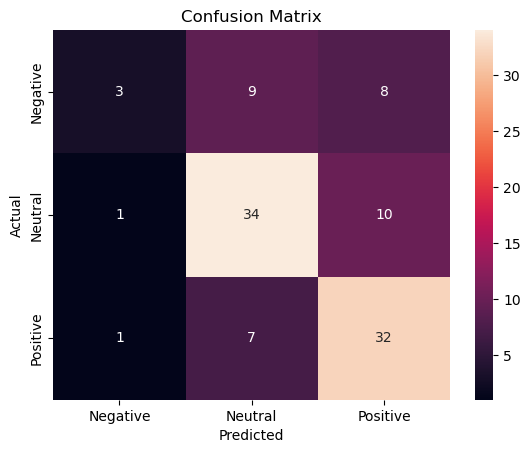


Topic 1:
['stop', 'global', 'like', 'gas', 'would', 'temperature', 'people', 'warming', 'co', 'year']

Topic 2:
['ano', 'earth', 'know', 'warming', 'year', 'de', 'change', 'global', 'people', 'climate']

Topic 3:
['keep', 'maybe', 'denier', 'one', 'going', 'year', 'change', 'data', 'climate', 'nasa']

Topic 4:
['time', 'it', 'know', 'temperature', 'energy', 'sun', 'planet', 'earth', 'climate', 'change']

Topic 5:
['rise', 'co', 'sea', 'foot', 'atmosphere', 'water', 'dioxide', 'level', 'year', 'carbon']


C:\Users\OWAIS\AppData\Local\Temp\ipykernel_2996\3933562301.py:168: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  nasa_df["month"] = nasa_df["date"].dt.to_period("M")


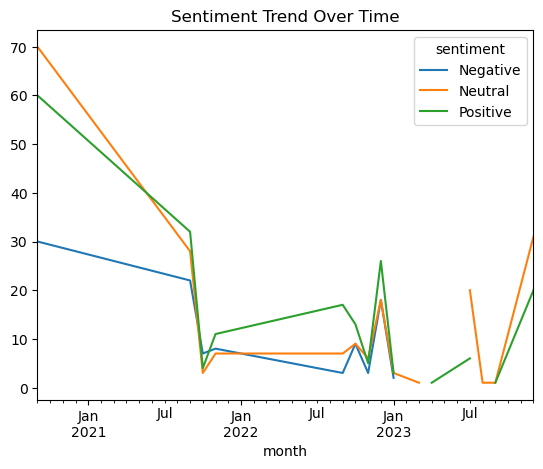


🚀 FULL ADVANCED PIPELINE COMPLETED SUCCESSFULLY!


In [1]:
# ADVANCED NASA SOCIAL MEDIA NLP PIPELINE

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')

# ==========================================
# 1️⃣ Load Dataset
# ==========================================

file_path = "climate_nasa.csv"   # Change if needed
nasa_df = pd.read_csv(file_path)

print("Dataset Shape:", nasa_df.shape)
print("\nColumns:", nasa_df.columns)

# ==========================================
# 2️⃣ Clean Text
# ==========================================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# ✅ Use correct column name: "text"
nasa_df["clean_text"] = nasa_df["text"].astype(str).apply(clean_text)

print("Text cleaning completed ✅")

# ==========================================
# 3️⃣ Sentiment Analysis (VADER)
# ==========================================

sia = SentimentIntensityAnalyzer()

nasa_df["sentiment_score"] = nasa_df["clean_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

nasa_df["sentiment"] = nasa_df["sentiment_score"].apply(label_sentiment)

print("\nSentiment Distribution:")
print(nasa_df["sentiment"].value_counts())

# ==========================================
# 4️⃣ Sentiment Distribution Plot
# ==========================================

plt.figure()
sns.countplot(data=nasa_df, x="sentiment")
plt.title("Sentiment Distribution")
plt.show()

# ==========================================
# 5️⃣ WordCloud
# ==========================================

all_text = " ".join(nasa_df["clean_text"])

wordcloud = WordCloud(width=800, height=400).generate(all_text)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of NASA Comments")
plt.show()

# ==========================================
# 6️⃣ ML Model (TF-IDF + Logistic Regression)
# ==========================================

X = nasa_df["clean_text"]
y = nasa_df["sentiment"]

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================================
# 7️⃣ Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# 8️⃣ Topic Modeling (LDA)
# ==========================================

count_vectorizer = CountVectorizer(max_features=1000)
X_counts = count_vectorizer.fit_transform(nasa_df["clean_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_counts)

words = count_vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopic {idx + 1}:")
    print([words[i] for i in topic.argsort()[-10:]])

# ==========================================
# 9️⃣ Sentiment Trend Over Time
# ==========================================

nasa_df["date"] = pd.to_datetime(nasa_df["date"], errors='coerce')
nasa_df["month"] = nasa_df["date"].dt.to_period("M")

trend = nasa_df.groupby(["month", "sentiment"]).size().unstack()

trend.plot()
plt.title("Sentiment Trend Over Time")
plt.show()

# ==========================================
# 🔟 Save Output
# ==========================================

nasa_df.to_csv("advanced_nasa_sentiment_analysis.csv", index=False)

print("\n🚀 FULL ADVANCED PIPELINE COMPLETED SUCCESSFULLY!")
